# Data Science Bowl 2018 - StarDist2D 직접 학습

이 노트북은 `data-science-bowl-2018/stage1_train`의 `images/*.png`와 `masks/*.png`를 직접 읽어 StarDist2D 모델을 학습합니다.

- 입력: grayscale 1채널 `(None, None, None, 1)`
- 출력: `prob` 1채널 + `dist` 32 rays
- 모델 설정: `n_rays=32`, `unet_n_depth=3`, `unet_n_filter_base=32`
- ground truth: 각 이미지 폴더의 여러 binary mask PNG를 하나의 instance label image로 병합

VS Code/Jupyter에서 **Run All** 하면 데이터 확인 → GT 생성 → 모델 생성 → 학습 → threshold 최적화 → 예측 샘플 확인 순서로 실행됩니다.

## CUDA/WSL 실행 안내

WSL CUDA 환경에서는 VS Code 노트북 우측 상단 Kernel을 **`DSB StarDist CUDA`**로 선택한 뒤 **Restart Kernel → Run All** 하세요. 이 kernel은 venv 안의 CUDA/cuDNN pip 라이브러리를 `LD_LIBRARY_PATH`에 포함해 TensorFlow가 `/GPU:0`을 사용하도록 만든 실행 환경입니다.


In [1]:
# 필요한 패키지가 없으면 설치합니다.
# Apple Silicon macOS에서는 MPS/Metal용 tensorflow-macos + tensorflow-metal을 설치합니다.
# Windows/WSL/Linux CUDA 환경에서는 tensorflow[and-cuda]를 사용하세요.
import sys
import platform
import subprocess
import importlib.util

IS_MAC_ARM = sys.platform == 'darwin' and platform.machine().lower() in {'arm64', 'aarch64'}
IS_LINUX = sys.platform.startswith('linux')

required = {
    'stardist': 'stardist>=0.9.1',
    'csbdeep': 'csbdeep>=0.8.0',
    'tensorflow': 'tensorflow-macos' if IS_MAC_ARM else ('tensorflow[and-cuda]' if IS_LINUX else 'tensorflow'),
    'skimage': 'scikit-image',
    'imageio': 'imageio',
    'tqdm': 'tqdm',
    'matplotlib': 'matplotlib',
    'pandas': 'pandas',
    'tensorboard': 'tensorboard',
}
if IS_MAC_ARM:
    required['tensorflow_metal'] = 'tensorflow-metal'
if IS_LINUX:
    # `tensorflow`만 설치되어 있고 CUDA extra가 빠진 경우를 잡기 위한 확인입니다.
    required['nvidia.cudnn'] = 'tensorflow[and-cuda]'
    required['nvidia.cublas'] = 'tensorflow[and-cuda]'

missing = sorted(set(pkg for module, pkg in required.items() if importlib.util.find_spec(module) is None))
if missing:
    print('Installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('All required packages are already installed.')


All required packages are already installed.


In [2]:
from pathlib import Path
from datetime import datetime
import os
import sys
import random

import numpy as np

# ===== CUDA 라이브러리 경로 설정 =====
# WSL/Linux에서 `tensorflow[and-cuda]`로 설치된 CUDA/cuDNN 라이브러리를 TensorFlow가 찾도록 합니다.
# 반드시 `import tensorflow as tf`보다 먼저 실행되어야 합니다.
def add_pip_nvidia_libs_to_ld_path():
    if not sys.platform.startswith('linux'):
        return []
    site_packages = Path(sys.prefix) / 'lib' / f'python{sys.version_info.major}.{sys.version_info.minor}' / 'site-packages'
    nvidia_dir = site_packages / 'nvidia'
    if not nvidia_dir.exists():
        return []
    lib_dirs = sorted(str(path) for path in nvidia_dir.glob('*/lib') if path.is_dir())
    if not lib_dirs:
        return []
    current = os.environ.get('LD_LIBRARY_PATH', '')
    existing = [path for path in current.split(':') if path]
    merged = lib_dirs + [path for path in existing if path not in lib_dirs]
    os.environ['LD_LIBRARY_PATH'] = ':'.join(merged)
    return lib_dirs

CUDA_PIP_LIB_DIRS = add_pip_nvidia_libs_to_ld_path()
if CUDA_PIP_LIB_DIRS:
    print('Added CUDA pip library dirs:', len(CUDA_PIP_LIB_DIRS))

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from imageio.v3 import imread
from skimage.color import rgb2gray, rgba2rgb
from skimage.segmentation import find_boundaries

import tensorflow as tf
from csbdeep.utils import normalize
from stardist import fill_label_holes, random_label_cmap
from stardist.models import Config2D, StarDist2D

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print('TensorFlow:', tf.__version__)

# ===== Device 설정 =====
# MPS는 macOS Apple Silicon + tensorflow-metal 환경에서만 사용 가능합니다.
# Windows/WSL CUDA 환경에서는 NVIDIA GPU(`/GPU:0`)를 우선 사용합니다.
DEVICE_PREFERENCE = 'cuda'  # 'mps', 'cuda', 'auto', 'cpu'

physical_gpus = tf.config.list_physical_devices('GPU')
for gpu in physical_gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as exc:
        print(f'Memory growth could not be set for {gpu}: {exc}')

logical_gpus = tf.config.list_logical_devices('GPU')
pluggable_devices = tf.config.list_logical_devices('PluggableDevice')

if DEVICE_PREFERENCE == 'mps':
    if pluggable_devices:
        DEVICE_NAME = pluggable_devices[0].name
        DEVICE_KIND = 'Apple Metal/MPS PluggableDevice'
    elif sys.platform == 'darwin' and logical_gpus:
        DEVICE_NAME = logical_gpus[0].name
        DEVICE_KIND = 'Apple Metal/MPS via TensorFlow GPU device'
    else:
        raise RuntimeError(
            'MPS device를 찾지 못했습니다. MPS는 macOS Apple Silicon에서 tensorflow-metal이 설치되어야 사용 가능합니다. '
            'Windows/WSL에서는 DEVICE_PREFERENCE를 cuda 또는 auto로 바꾸세요.'
        )
elif DEVICE_PREFERENCE == 'cuda':
    if logical_gpus:
        DEVICE_NAME = logical_gpus[0].name
        DEVICE_KIND = 'CUDA/TensorFlow GPU'
    else:
        raise RuntimeError('CUDA GPU를 찾지 못했습니다. WSL에서는 NVIDIA 드라이버와 tensorflow[and-cuda] 설치를 확인하세요.')
elif DEVICE_PREFERENCE == 'cpu':
    DEVICE_NAME = '/CPU:0'
    DEVICE_KIND = 'CPU'
else:
    if pluggable_devices:
        DEVICE_NAME = pluggable_devices[0].name
        DEVICE_KIND = 'Apple Metal/MPS PluggableDevice'
    elif logical_gpus:
        DEVICE_NAME = logical_gpus[0].name
        DEVICE_KIND = 'CUDA/TensorFlow GPU'
    else:
        DEVICE_NAME = '/CPU:0'
        DEVICE_KIND = 'CPU'

print('Physical GPUs:', physical_gpus)
print('Logical GPUs:', logical_gpus)
print('Pluggable devices:', pluggable_devices)
print('Selected device:', DEVICE_NAME, '|', DEVICE_KIND)


Added CUDA pip library dirs: 11


I0000 00:00:1780894861.879865   11202 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780894862.317828   11202 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780894863.515756   11202 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical GPUs: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]
Pluggable devices: []
Selected device: /device:GPU:0 | CUDA/TensorFlow GPU


W0000 00:00:1780894865.118684   11202 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1780894865.122029   11202 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1780894865.310333   11202 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5219 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [3]:
# ===== 사용자 설정 =====
# ===== 경로 설정 =====
# 노트북을 어디로 옮겨도, 현재 작업 디렉터리 또는 그 상위 폴더에서
# `data-science-bowl-2018` 폴더를 찾아 상대경로 기반으로 동작합니다.
# 권장 실행 위치: 이 노트북이 있는 프로젝트 루트(`Data Science Bowl`).
PROJECT_DIR = Path.cwd().resolve()

# VS Code/Jupyter가 노트북 폴더가 아닌 다른 CWD에서 kernel을 시작하는 경우까지 대비합니다.
# 우선순위: 현재 CWD/상위 폴더 → 자주 쓰는 원격 프로젝트 경로 → 현재 CWD 하위 후보
PROJECT_CANDIDATES = [
    PROJECT_DIR,
    *PROJECT_DIR.parents,
    Path('/home/ksc/projects/stardistTest'),
    Path('/mnt/c/Users/labssh/projects/Data Science Bowl'),
    PROJECT_DIR / 'stardistTest',
    PROJECT_DIR / 'Data Science Bowl',
]

DATA_DIR = None
for base in PROJECT_CANDIDATES:
    candidate = (base / 'data-science-bowl-2018').expanduser()
    if candidate.exists():
        DATA_DIR = candidate.resolve()
        PROJECT_DIR = DATA_DIR.parent
        break

if DATA_DIR is None:
    checked = '\n'.join(str((base / 'data-science-bowl-2018').expanduser()) for base in PROJECT_CANDIDATES)
    raise FileNotFoundError(
        'data-science-bowl-2018 폴더를 찾지 못했습니다. '
        'VS Code에서 프로젝트 폴더를 열거나, 아래 경로 중 하나에 데이터 폴더가 있어야 합니다:\n' + checked
    )

TRAIN_DIR = DATA_DIR / 'stage1_train'
TEST_DIR = DATA_DIR / 'stage1_test'

# 실행할 때마다 새 모델 폴더를 만들어 기존 weights_best.h5를 덮어쓰지 않습니다.
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
MODEL_NAME = f'stardist_dsb2018_from_scratch_{RUN_ID}'
MODEL_BASEDIR = PROJECT_DIR / 'models'

# 빠른 동작 확인만 하고 싶으면 True로 바꾸세요.
# 실제 학습은 False 권장.
FAST_DEV_RUN = False
MAX_TRAIN_IMAGES = None if not FAST_DEV_RUN else 40

N_RAYS = 32
GRID = (1, 1)
PATCH_SIZE = (256, 256)
BATCH_SIZE = 2
EPOCHS = 80 if not FAST_DEV_RUN else 2
STEPS_PER_EPOCH = 200 if not FAST_DEV_RUN else 10
VALIDATION_SPLIT = 0.15
LEARNING_RATE = 3e-4

MODEL_BASEDIR.mkdir(exist_ok=True)
assert TRAIN_DIR.exists(), f'Train directory not found: {TRAIN_DIR.resolve()}'
print('Train dir:', TRAIN_DIR.resolve())

Train dir: /home/ksc/projects/stardistTest/data-science-bowl-2018/stage1_train


In [4]:
def list_image_ids(train_dir: Path):
    ids = []
    for p in sorted(train_dir.iterdir()):
        if not p.is_dir():
            continue
        image_files = list((p / 'images').glob('*.png'))
        mask_files = list((p / 'masks').glob('*.png'))
        if image_files and mask_files:
            ids.append(p.name)
    return ids

image_ids = list_image_ids(TRAIN_DIR)
if MAX_TRAIN_IMAGES is not None:
    image_ids = image_ids[:MAX_TRAIN_IMAGES]

print(f'Usable training images: {len(image_ids)}')
print('First 3 IDs:', image_ids[:3])

Usable training images: 670
First 3 IDs: ['00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552', '003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1', '00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e']


In [5]:
def read_grayscale01(path: Path) -> np.ndarray:
    """Read PNG/RGBA/RGB/grayscale image and return float32 grayscale in [0, 1]."""
    img = imread(path)
    if img.ndim == 2:
        gray = img.astype(np.float32)
    elif img.ndim == 3 and img.shape[-1] == 4:
        rgb = rgba2rgb(img.astype(np.float32) / 255.0)
        gray = rgb2gray(rgb).astype(np.float32)
        return gray
    elif img.ndim == 3 and img.shape[-1] >= 3:
        rgb = img[..., :3].astype(np.float32)
        if rgb.max() > 1:
            rgb = rgb / 255.0
        gray = rgb2gray(rgb).astype(np.float32)
        return gray
    else:
        raise ValueError(f'Unsupported image shape {img.shape} for {path}')

    if gray.max() > 1:
        gray = gray / np.iinfo(img.dtype).max if np.issubdtype(img.dtype, np.integer) else gray / gray.max()
    return gray.astype(np.float32)


def load_instance_label(image_id: str) -> np.ndarray:
    """Merge one binary PNG per nucleus into a single integer instance label image."""
    image_path = next((TRAIN_DIR / image_id / 'images').glob('*.png'))
    image_shape = read_grayscale01(image_path).shape
    label = np.zeros(image_shape, dtype=np.uint16)
    mask_paths = sorted((TRAIN_DIR / image_id / 'masks').glob('*.png'))
    for instance_id, mask_path in enumerate(mask_paths, start=1):
        mask = imread(mask_path)
        if mask.ndim == 3:
            mask = mask[..., 0]
        mask = mask > 0
        if mask.shape != image_shape:
            raise ValueError(f'Mask shape mismatch for {image_id}: {mask.shape} != {image_shape}')
        label[mask] = instance_id
    return fill_label_holes(label)


def load_image_and_label(image_id: str):
    image_path = next((TRAIN_DIR / image_id / 'images').glob('*.png'))
    image = read_grayscale01(image_path)
    label = load_instance_label(image_id)
    return image, label

Sample ID: 00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552
image: (256, 256) float32 0.003921568859368563 0.42352941632270813
label: (256, 256) uint16 instances: 27


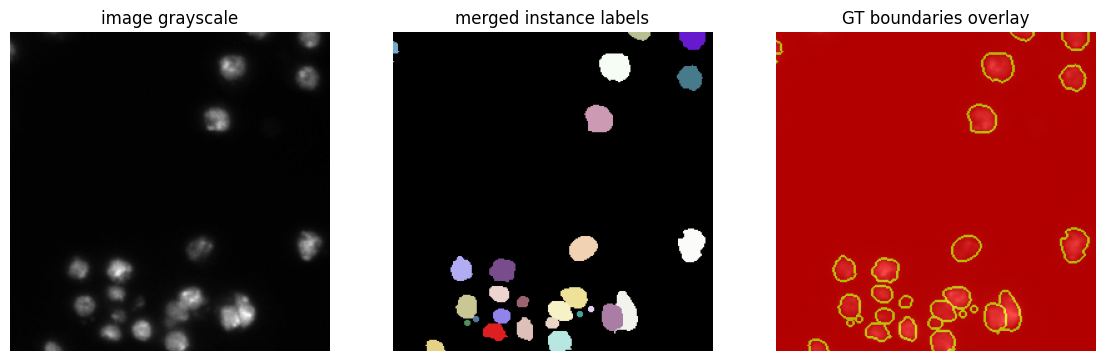

In [6]:
# ground truth가 실제로 잘 만들어지는지 확인합니다.
if len(image_ids) == 0:
    raise ValueError(f'No usable training images found in {TRAIN_DIR.resolve()}')

sample_id = image_ids[0]
sample_x, sample_y = load_image_and_label(sample_id)
print('Sample ID:', sample_id)
print('image:', sample_x.shape, sample_x.dtype, float(sample_x.min()), float(sample_x.max()))
print('label:', sample_y.shape, sample_y.dtype, 'instances:', int(sample_y.max()))

plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
plt.imshow(sample_x, cmap='gray')
plt.title('image grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sample_y, cmap=random_label_cmap())
plt.title('merged instance labels')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sample_x, cmap='gray')
plt.imshow(find_boundaries(sample_y), cmap='autumn', alpha=0.7)
plt.title('GT boundaries overlay')
plt.axis('off')
plt.show()

In [7]:
X, Y = [], []
for image_id in tqdm(image_ids, desc='Loading images and masks'):
    x, y = load_image_and_label(image_id)
    X.append(x)
    Y.append(y)

# StarDist 권장 방식: percentile normalization
X = [normalize(x, 1, 99.8, axis=(0, 1)).astype(np.float32) for x in X]
Y = [y.astype(np.uint16) for y in Y]

assert len(X) == len(Y) > 0
assert all(x.shape == y.shape for x, y in zip(X, Y))
print('Loaded:', len(X), 'images')
print('Shape examples:', [x.shape for x in X[:5]])
print('Instance count examples:', [int(y.max()) for y in Y[:5]])

Loading images and masks:   0%|          | 0/670 [00:00<?, ?it/s]

Loaded: 670 images
Shape examples: [(256, 256), (256, 256), (256, 320), (256, 320), (256, 320)]
Instance count examples: [27, 36, 70, 86, 7]


In [8]:
# deterministic train/validation split
if len(X) < 2:
    raise ValueError(f'At least 2 images are required for train/validation split, got {len(X)}.')

rng = np.random.default_rng(SEED)
indices = np.arange(len(X))
rng.shuffle(indices)
n_val = max(1, int(round(len(indices) * VALIDATION_SPLIT)))
n_val = min(n_val, len(indices) - 1)
if n_val < 1:
    raise ValueError(f'Validation split produced 0 validation images from {len(indices)} images.')
val_idx = indices[:n_val]
train_idx = indices[n_val:]
assert len(train_idx) > 0 and len(val_idx) > 0, (len(train_idx), len(val_idx))

X_train = [X[i] for i in train_idx]
Y_train = [Y[i] for i in train_idx]
X_val = [X[i] for i in val_idx]
Y_val = [Y[i] for i in val_idx]

print('Train:', len(X_train), 'Validation:', len(X_val))

Train: 570 Validation: 100


In [9]:
def random_fliprot(x, y):
    k = np.random.randint(4)
    x = np.rot90(x, k)
    y = np.rot90(y, k)
    if np.random.rand() > 0.5:
        x = np.fliplr(x)
        y = np.fliplr(y)
    if np.random.rand() > 0.5:
        x = np.flipud(x)
        y = np.flipud(y)
    return x, y


def augmenter(x, y):
    x, y = random_fliprot(x, y)
    # mild intensity augmentation for microscopy variation
    scale = np.random.uniform(0.9, 1.1)
    shift = np.random.uniform(-0.05, 0.05)
    x = np.clip(x * scale + shift, 0, 1)
    return x, y

In [10]:
conf = Config2D(
    n_rays=N_RAYS,
    grid=GRID,
    n_channel_in=1,
    train_patch_size=PATCH_SIZE,
    train_batch_size=BATCH_SIZE,
    train_epochs=EPOCHS,
    train_steps_per_epoch=STEPS_PER_EPOCH,
    train_learning_rate=LEARNING_RATE,
    unet_n_depth=3,
    unet_n_filter_base=32,
    unet_n_conv_per_depth=2,
)
print(conf)

# 기존 같은 이름의 모델 폴더가 있으면 이어서 사용할 수 있습니다.
# 완전히 새로 시작하려면 models/stardist_dsb2018_from_scratch 폴더를 삭제한 뒤 실행하세요.
with tf.device(DEVICE_NAME):
    model = StarDist2D(conf, name=MODEL_NAME, basedir=str(MODEL_BASEDIR))
model.keras_model.summary()

Config2D(n_dim=2, axes='YXC', n_channel_in=1, n_channel_out=33, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=32, grid=(1, 1), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=(3, 3), unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=(2, 2), unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_expansion=2, unet_prefix='', net_conv_after_unet=128, net_input_shape=(None, None, 1), net_mask_shape=(None, None, 1), train_shape_completion=False, train_completion_crop=32, train_patch_size=(256, 256), train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=(1, 0.2), train_class_weights=(1, 1), train_epochs=80, train_steps_per_epoch=200, train_learning_rate=0.0003, train_batch_size=2, train_n_val_patches=None, train_tensorboard=True, train_reduce_lr={'factor': 0.5, 'patience': 40, 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, None,      │          0 │ -                 │
│                     │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down_level_0_no_0   │ (None, None,      │        320 │ input[0][0]       │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down_level_0_no_1   │ (None, None,      │      9,248 │ down_level_0_no_… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_0               │ (None, None,      │          0 │ down_level_0_no_… │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down_level_1_no_0   │ (None, None,      │     18,496 │ max_0[0][0]       │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down_level_1_no_1   │ (None, None,      │     36,928 │ down_level_1_no_… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_1               │ (None, None,      │          0 │ down_level_1_no_… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down_level_2_no_0   │ (None, None,      │     73,856 │ max_1[0][0]       │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ down_level_2_no_1   │ (None, None,      │    147,584 │ down_level_2_no_… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_2               │ (None, None,      │          0 │ down_level_2_no_… │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ middle_0 (Conv2D)   │ (None, None,      │    295,168 │ max_2[0][0]       │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ middle_2 (Conv2D)   │ (None, None,      │    295,040 │ middle_0[0][0]    │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, None,      │          0 │ middle_2[0][0]    │
│ (UpSampling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None,      │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ None, 256)        │            │ down_level_2_no_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_level_2_no_0     │ (None, None,      │    295,040 │ concatenate[0][0] │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_level_2_no_2     │ (None, None,      │     73,792 │ up_level_2_no_0[… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, None,      │          0 │ up_level_2_no_2[

 Total params: 1,406,689 (5.37 MB)

 Trainable params: 1,406,689 (5.37 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 직접 학습 시작
# Mac/CPU 환경에서는 시간이 오래 걸릴 수 있습니다. 먼저 FAST_DEV_RUN=True로 smoke test 후 False로 돌리는 것을 권장합니다.
with tf.device(DEVICE_NAME):
    history = model.train(
        X_train,
        Y_train,
        validation_data=(X_val, Y_val),
    augmenter=augmenter,
)

Epoch 1/80


I0000 00:00:1780894901.693002   11202 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1780894903.529759   11533 service.cc:153] XLA service 0x7ef53c052c00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780894903.529795   11533 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780894903.610846   11533 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780894905.403868   11533 cuda_dnn.cc:461] Loaded cuDNN version 92300
W0000 00:00:1780894907.102923   11533 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold

  5/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - dist_dist_iou_metric: 1.3443e-06 - dist_loss: 9.2795 - dist_relevant_mae: 9.2795 - dist_relevant_mse: 151.6900 - loss: 2.5442 - prob_kld: 0.6545 - prob_loss: 0.6883

I0000 00:00:1780894917.396125   11533 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - dist_dist_iou_metric: 0.1147 - dist_loss: 9.9644 - dist_relevant_mae: 9.9641 - dist_relevant_mse: 188.5737 - loss: 2.3976 - prob_kld: 0.3320 - prob_loss: 0.4048

W0000 00:00:1780894936.535023   11532 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.18GiB (rounded to 4489544448)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1780894936.535134   11532 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1780894936.535140   11532 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 1673, Chunks in use: 1673. 418.2KiB allocated for chunks. 418.2KiB in use in bin. 12.5KiB client-requested in use in bin.
I0000 00:00:1780894936.535145   11532 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 18, Chunks in use: 18. 9.0KiB allocated for chunks. 9.0KiB in use in bin. 9.0KiB client-requested in use in bin.
I0000 00:00:1780894936.535149   11532 bfc_allocator.cc:1056] Bin (1024): 	Total Chunks: 8, Chunks in use: 7. 9.2KiB allocated

200/200 ━━━━━━━━━━━━━━━━━━━━ 71s 278ms/step - dist_dist_iou_metric: 0.2144 - dist_loss: 8.6028 - dist_relevant_mae: 8.6022 - dist_relevant_mse: 154.6080 - loss: 2.0543 - prob_kld: 0.2577 - prob_loss: 0.3337 - val_dist_dist_iou_metric: 0.3633 - val_dist_loss: 6.7522 - val_dist_relevant_mae: 6.7511 - val_dist_relevant_mse: 91.6236 - val_loss: 1.6831 - val_prob_kld: 0.2622 - val_prob_loss: 0.3327 - learning_rate: 3.0000e-04
Epoch 2/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - dist_dist_iou_metric: 0.3402 - dist_loss: 6.5025 - dist_relevant_mae: 6.5012 - dist_relevant_mse: 94.5407 - loss: 1.5259 - prob_kld: 0.1528 - prob_loss: 0.2254 - val_dist_dist_iou_metric: 0.3580 - val_dist_loss: 5.9331 - val_dist_relevant_mae: 5.9316 - val_dist_relevant_mse: 83.8973 - val_loss: 1.3739 - val_prob_kld: 0.1168 - val_prob_loss: 0.1872 - learning_rate: 3.0000e-04
Epoch 3/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - dist_dist_iou_metric: 0.3924 - dist_loss: 5.7730 - dist_relevant_mae: 5.7715 - dist_rel

In [ ]:
# validation set으로 NMS/probability threshold 최적화
model.optimize_thresholds(X_val, Y_val)
print('Optimized thresholds:', model.thresholds)

In [ ]:
# 학습 곡선 확인
hist = history.history
plt.figure(figsize=(12, 4))
for i, key in enumerate(['loss', 'prob_loss', 'dist_loss']):
    if key in hist:
        plt.plot(hist[key], label=key)
    val_key = 'val_' + key
    if val_key in hist:
        plt.plot(hist[val_key], label=val_key)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# validation sample 예측 확인
sample_i = 0
x = X_val[sample_i]
y_true = Y_val[sample_i]
y_pred, details = model.predict_instances(x)

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.imshow(x, cmap='gray')
plt.title('validation image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(y_true, cmap=random_label_cmap())
plt.title(f'GT instances: {int(y_true.max())}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(x, cmap='gray')
plt.imshow(find_boundaries(y_pred), cmap='autumn', alpha=0.8)
plt.title(f'Prediction instances: {int(y_pred.max())}')
plt.axis('off')
plt.show()

In [ ]:
# stage1_test 또는 stage2_test_final 예측용 헬퍼
# Kaggle 제출용 RLE까지 만들고 싶으면 아래 함수들을 사용하세요.
def rle_encode(mask: np.ndarray) -> str:
    """Kaggle DSB2018 column-major RLE for one binary instance mask."""
    pixels = mask.T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)


def predict_folder_to_rles(test_dir: Path):
    rows = []
    test_ids = sorted([p.name for p in test_dir.iterdir() if p.is_dir()])
    for image_id in tqdm(test_ids, desc=f'Predicting {test_dir.name}'):
        image_path = next((test_dir / image_id / 'images').glob('*.png'))
        x = normalize(read_grayscale01(image_path), 1, 99.8, axis=(0, 1)).astype(np.float32)
        labels, _ = model.predict_instances(x)
        if labels.max() == 0:
            rows.append({'ImageId': image_id, 'EncodedPixels': ''})
        else:
            for instance_id in range(1, int(labels.max()) + 1):
                encoded = rle_encode(labels == instance_id)
                if encoded:
                    rows.append({'ImageId': image_id, 'EncodedPixels': encoded})
    return rows

print('Prediction helper ready. Example: rows = predict_folder_to_rles(TEST_DIR)')

In [ ]:
# 선택 실행: stage1_test 제출 파일 생성
# if TEST_DIR.exists():
#     import pandas as pd
#     rows = predict_folder_to_rles(TEST_DIR)
#     sub = pd.DataFrame(rows, columns=['ImageId', 'EncodedPixels'])
#     out_path = Path('submission_stardist_stage1_test.csv')
#     sub.to_csv(out_path, index=False)
#     print('Saved:', out_path.resolve(), sub.shape)